# LightGBM model tuning

## Import packages and data

In [2]:
import pandas as pd
import gc
import matplotlib.pyplot as plt
import optuna
import lightgbm as lgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_score, recall_score, ConfusionMatrixDisplay, confusion_matrix, roc_curve
from lightgbm.callback import early_stopping, log_evaluation
from optuna.visualization import plot_slice, plot_param_importances, plot_optimization_history

In [3]:
path_to_data = "~/PycharmProjects/home-credit-default-risk/data/processed/"
# path_to_data = "/content/drive/MyDrive/Home_Credit_data/"

application_train_df = pd.read_csv(path_to_data+"application_train.csv")
print(application_train_df.shape)
# application_test_df = pd.read_csv(path_to_data+"application_test.csv")

(307511, 722)


## Split into train and val

In [4]:
y = application_train_df.pop("TARGET")
application_train_df.pop("SK_ID_CURR")
X = application_train_df

In [5]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [6]:
del X
del application_train_df
gc.collect()

20

## Categorical features

In [7]:
cat_cols = X_train.select_dtypes(include = 'object').columns.tolist()
len(cat_cols)

16

In [8]:
for col in cat_cols:
    categories = X_train[col].dropna().unique()
    X_train[col] = pd.Categorical(X_train[col], categories = categories)
    X_val[col] = pd.Categorical(X_val[col], categories = categories)


In [9]:
X_train.select_dtypes(include='object').columns

Index([], dtype='object')

## LightGBM with optuna

We used the second model LightGBM based on the "application_train" features.

In [ ]:

def objective_lgbm(trial):
    max_depth = trial.suggest_int("max_depht", 2, 10)
    num_leaves = trial.suggest_int("num_leaves", 8, min(2 ** max_depth, 128))
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.15, log=True)
    min_child_samples = trial.suggest_int("min_child_samples", 20, 200)
    min_split_gain = trial.suggest_float("min_split_gain", 0.0, 2.0)
    subsample = trial.suggest_float("subsample", 0.6, 1.0)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0)

    model = lgbm.LGBMClassifier(
        objective="binary",
        n_estimators=3000,
        learning_rate=learning_rate,
        max_depth=max_depth,
        num_leaves=num_leaves,
        min_child_samples=min_child_samples,
        min_split_gain=min_split_gain,
        subsample=subsample,
        subsample_freq=1,
        colsample_bytree=colsample_bytree,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric="auc", categorical_feature=cat_cols, callbacks=[early_stopping(stopping_rounds=100, first_metric_only=True, verbose=False), log_evaluation(0)])

    proba = model.predict_proba(X_val, num_iteration=model.best_iteration_)[:, 1]
    auc = roc_auc_score(y_val, proba)
    trial.set_user_attr("best_iteration", model.best_iteration_)

    return auc

In [ ]:
study_lgbm_opt = optuna.create_study(direction = "maximize", sampler=optuna.samplers.TPESampler(seed=42)
study_lgbm_opt.optimize(objective_lgbm, n_trials = 50, show_progress_bar = True, n_jobs=1, gc_after_trial=True,)

In [ ]:
best_params_lgbm = study_lgbm_opt.best_params
best_params_lgbm

In [ ]:
best_val_lgbm = study_lgbm_opt.best_value
best_val_lgbm

In [ ]:
%%time

lgbm_optuna = LGBMClassifier(
    objective = "binary",
    n_estimators = 500,
    **study_lgbm_opt.best_params,
    subsample_freq = 1,
    random_state = 42,
    n_jobs = -1,
    verbosity = -1
)

lgbm_optuna.fit(X_train, y_train, eval_set = [(X_val, y_val)], eval_metric = "auc", callbacks = [early_stopping(stopping_rounds = 20, first_metric_only = True, verbose = False), log_evaluation(period = 0)])
lgbm_optuna_proba = lgbm_optuna.predict_proba(X_test, num_iteration = lgbm_optuna.best_iteration_)[:, 1]
lgbm_optuna_pred = (lgbm_optuna_proba >= 0.5).astype(int)

lgbm_roc_auc_opt = roc_auc_score(y_test, lgbm_optuna_proba)
lgbm_accuracy_opt = accuracy_score(y_test, lgbm_optuna_pred)
lgbm_log_loss_opt = log_loss(y_test, lgbm_optuna_proba)
lgbm_precision_opt = precision_score(y_test, lgbm_optuna_pred, zero_division = 0)
lgbm_recall_opt = recall_score(y_test, lgbm_optuna_pred, zero_division = 0)
lgbm_average_precision_opt = average_precision_score(y_test, lgbm_optuna_proba)

print("Лучшая итерация:", lgbm_optuna.best_iteration_)
print("ROC-AUC:", lgbm_roc_auc_opt)
print("Accuracy:", lgbm_accuracy_opt)
print("Log loss:", lgbm_log_loss_opt)
print("Precision:", lgbm_precision_opt)
print("Recall:", lgbm_recall_opt)
print("Average Precision:", lgbm_average_precision_opt)

## LightGBM without optuna

In [16]:
lgb_clf = lgb.LGBMClassifier(n_estimators=1000, max_depth=4, class_weight="balanced", learning_rate=0.1, random_state = 42, n_jobs=-1)
lgb_clf.fit(X_train, y_train, eval_set = [(X_val, y_val)], eval_metric='auc', categorical_feature=cat_cols, callbacks = [early_stopping(stopping_rounds=100), log_evaluation(period = 1)])

threshold = 0.5
val_pred_proba = lgb_clf.predict_proba(X_val)[:, 1]
val_pred = (val_pred_proba >= threshold).astype(int)


roc_auc_lgb = roc_auc_score(y_val, val_pred_proba)
prec_lgb = precision_score(y_val, val_pred, zero_division=0)
rec_lgb = recall_score(y_val, val_pred, zero_division=0)

print("Best_iteration:", lgb_clf.best_iteration_)
print("ROC-AUC_lgb:", roc_auc_lgb)
print("Precision_lgb:", prec_lgb)
print("Recall_lgb:", rec_lgb)

/home/usl/PycharmProjects/home-credit-default-risk/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023001 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11379
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 115
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[1]	valid_0's auc: 0.702587	valid_0's binary_logloss: 0.680939
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[2]	valid_0's auc: 0.710066	valid_0's binary_logloss: 0.670672
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[3]	valid_0's auc: 0.713546

Text(0.5, 1.0, 'Confusion Matrix LightGBM')

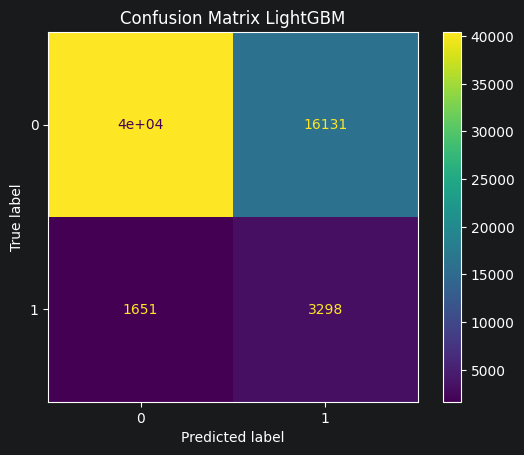

In [17]:
ConfusionMatrixDisplay.from_predictions(y_val, val_pred)
plt.title("Confusion Matrix LightGBM")

And now we will calculate the roc_curve and plot a graph:

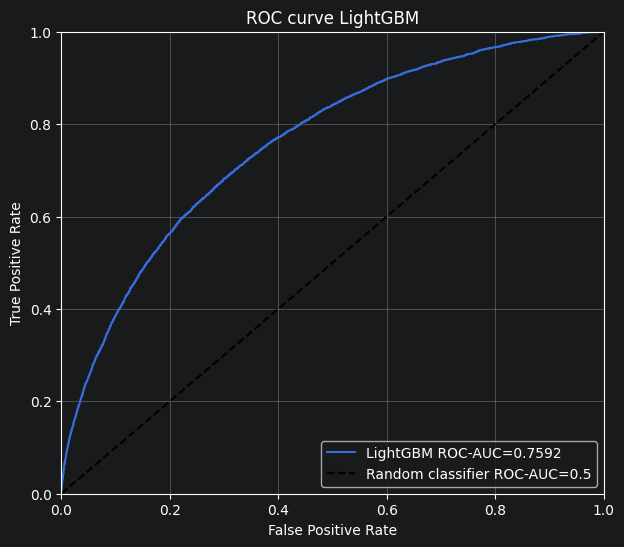

In [14]:
fpr, tpr, thresholds = roc_curve(y_val, val_pred_proba)
plt.figure(figsize=(7, 6))

plt.plot(fpr, tpr, label = f"LightGBM ROC-AUC={roc_auc_lgb:.4f}")
plt.plot([0, 1], [0, 1], 'k--', label = "Random classifier ROC-AUC=0.5")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve LightGBM")
plt.legend(loc="lower right")
plt.grid()

We will prepare the test part for training:

In [15]:
application_test_df.shape

(48744, 120)

In [16]:
X_test = application_test_df

In [17]:
for col in cat_cols:
    X_test[col] = pd.Categorical(X_test[col], categories = X_train[col].cat.categories)
X_test.shape, X_train.shape

((48744, 120), (246008, 120))

In [18]:
list(X_train.columns) == list(X_test.columns)

True

In [19]:
test_pred_proba = lgb_clf.predict_proba(X_test)[:, 1]

In [20]:
submission = sample_submission_df.copy()
submission["TARGET"] = test_pred_proba
submission.head()

,SK_ID_CURR,TARGET
0,100001,0.041798
1,100005,0.141336
2,100013,0.039745
3,100028,0.039389
4,100038,0.147843


In [21]:
submission.shape, application_test_df.shape

((48744, 2), (48744, 120))

In [22]:
submission.to_csv("submission_lgb_baseline.csv", index=False)